# Layer I — Li-ion Battery Physical Degradation Model
### An offline, step-by-step, self-contained engine that generates the α / cₖ / β surrogates for MicroGridsPy

This notebook builds the **Layer I physical model** of the *degradation-aware off-grid sizing*
workflow (Andrade 2023, extended with depth-resolved cycle aging). It is written to be read
top-to-bottom: every sub-model is introduced with its equations, implemented with commented
code, and visualized.

**Two goals**
1. A **fully functional, transparent Layer I** for two commercial cells (one LFP, one NMC),
   split into documented steps for research development.
2. A **distillation engine** that emits the `α(T)` calendar cubics, the depth-resolved
   `cₖ(T)` band marginals, and legacy `β(T,DoD)` cubics in the **exact structure MicroGridsPy
   consumes** — so the offline physics can drive the online MILP.

**Pipeline**

```
Inputs (datasheet)  →  Electrical  →  Thermal  →  SEM (calendar+cycle)  →  Calibration
                                                                              │
                    Distillation ──────────────────────────────────────────┘
                    α(T,SoC)   |   Ψ(D,T) → cₖ(T) bands   |   β(T,DoD) legacy
                                                                              │
                    Self-consistency test  →  Export (mgpy JSON)  →  Custom-battery flow
```

> **Scope & honesty box.**
> - **Li-ion only.** Lead-acid needs the Schiffer model (separate module).
> - **Single cell + a lumped `dt_pack` offset** for pack self-heating (intra-pack *gradients*
>   are still not resolved — a scalar rise, not a field).
> - **What is *inherited*:** the semi-empirical aging *laws* and their coefficients
>   (`a₁..a₅` calendar, Ali et al. 2023; `b₁..b₈` cycle, Olmos et al. 2021).
> - **What is *ours* (transparent, editable):** the datasheet inputs, the calibration
>   choice (anchor the cycle channel to the datasheet cycle-life EOL), the distillation
>   protocol, and the depth-band construction.
> - **No external cross-check here** (by design). This notebook proves *self-consistency*
>   (linearized surrogates vs. the full SEM), not ground truth — an external validation
>   anchor is required before publication.

## 1 · Imports & global configuration

In [1]:
from __future__ import annotations
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
import json, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

# ---- physical constants (air properties @300 K; §2.2) ----
SIGMA  = 5.670374419e-8   # Stefan-Boltzmann      [W m^-2 K^-4]
G      = 9.81             # gravity               [m s^-2]
K_AIR  = 0.0263           # air conductivity      [W m^-1 K^-1]
NU_AIR = 1.57e-5          # air kinematic visc.   [m^2 s^-1]
PR_AIR = 0.707            # air Prandtl number    [-]
KELVIN = 273.15

# ---- distillation protocol (editable) ----
TEMP_GRID_C   = np.array([10, 15, 20, 25, 30, 35, 40, 45], float)  # tabulation temperatures
SOC_BANDS     = {"20": 0.20, "40": 0.40}      # storage SoC levels for alpha (§3.1)
DOD_BANDS_LEG = np.array([0.5, 0.6, 0.7, 0.8, 0.9])  # legacy beta DoD bands (mgpy)
BAND_EDGES    = np.linspace(0.0, 1.0, 11)     # 10 depth bands for c_k (Psi anchored at 0)
HORIZON_YEARS = 20
CRATE_REF     = 0.4      # representative OFF-GRID C-rate used to distill c_k / beta and to
                         # size self-heating. NOTE: calibration uses each cell's datasheet
                         # test_crate (typically 1C) — see sec.7. Field cycling is gentler
                         # than the datasheet test, so 0.4C is the honest operating point.
DT_STEP_S     = 3600.0   # thermal integration timestep [s] (hourly). Used to fix eq 2.12.
print("config OK — temperatures:", TEMP_GRID_C.tolist(), "| distillation C-rate:", CRATE_REF)

config OK — temperatures: [10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0] | distillation C-rate: 0.4


## 2 · The approach in one paragraph

All nonlinearity and feedback live **here, offline**. We run a physics-grade tandem
(electrical → thermal → semi-empirical aging) on a single cell using datasheet inputs, then
**distill** three linear surrogates tabulated versus temperature:

- **α(T, SoC)** — calendar fade rate (always on), a cubic in `y = T[°C]/10`.
- **cₖ(T)** — *depth-resolved* marginal cycle-fade cost per SOC band, from the depth curve
  `Ψ(D,T)`. Because we have the full law, `Ψ` is **computed at any depth** (no extrapolation
  below 50 % DoD), and its band marginals feed a **binary-free convex** PWL in the MILP.
- **β(T, DoD)** — the legacy single-coefficient cycle term, for backward-compatibility with
  the current MicroGridsPy slot.

The online MILP then sees only constants × variables — it stays linear.

## 3 · Inputs — two commercial cells (fully editable)

Everything the physical model needs comes from a datasheet. Edit the two `CellSpec` blocks
to model your own cells. Fields group into: **electrical** (discharge-curve points), **thermal /
geometry**, the **inherited aging coefficients**, and the **calibration anchors** (the
datasheet cycle-life EOL point).

The `assumptions ledger` printed below lists every value that is *not* a direct datasheet read
— your defensibility surface / future methods section.

In [2]:
@dataclass
class CellSpec:
    name: str
    chemistry: str                       # "LFP" | "NMC"
    # --- electrical (datasheet discharge curve) ---
    C_max: float                         # rated capacity                    [Ah]
    V_full: float; V_exp: float; V_nom: float   # full / end-exp / end-nom V  [V]
    C_exp: float; C_nom: float           # charge at end-exp / end-nom       [Ah]
    I_d: float                           # reference discharge current       [A]
    R_int: float                         # internal resistance               [ohm]
    V_nominal: float                     # nominal voltage (Wh conversions)  [V]
    # --- thermal / geometry (per cell) ---
    mass: float; c_p: float; emissivity: float
    H_L: float; T_L: float; W_L: float   # height / thickness / width        [m]
    N_series: int; N_parallel: int; N_batteries: int
    # --- inherited aging-law coefficients ---
    a: tuple                             # a1..a5 calendar (Ali 2023)
    b: tuple                             # b1..b8 cycle    (Olmos 2021)
    # --- calibration anchors (datasheet) ---
    N_cycles: float                      # rated cycle life
    EOL_SOH: float                       # end-of-life SoH (e.g. 0.80)
    test_DOD: float                      # datasheet test DoD
    test_T_C: float                      # datasheet test temperature        [degC]
    test_crate: float                    # datasheet test C-rate
    # --- thermal assumption (L8 pack self-heating above room ambient) ---
    dt_pack: float = 3.0                 # extra cell temperature rise from pack packing/
                                         # ventilation, ADDED to single-cell self-heating [K]
    # --- optional provenance (NOT used on the datasheet-anchored path) ---
    C_b_study: float = 2.5               # lab-cell capacity the law was fit on [Ah]
    N_ref: float = 6000.0                # reference cycle life of the fitted shape

LFP = CellSpec(
    name="LFP 280Ah prismatic", chemistry="LFP",
    C_max=280.0, V_full=3.40, V_exp=3.32, V_nom=3.20, C_exp=14.0, C_nom=252.0,
    I_d=140.0, R_int=0.00025, V_nominal=3.2,
    mass=5.4, c_p=1000.0, emissivity=0.85, H_L=0.207, T_L=0.072, W_L=0.173,
    N_series=1, N_parallel=1, N_batteries=1,
    a=(0.00157, 1.317, 142300.0, -3492.0, 0.48),
    b=(0.003414, 5.8755, 293.0, -0.0046, 0.296, 0.1038, 0.0513, 0.42),
    N_cycles=6000.0, EOL_SOH=0.80, test_DOD=1.0, test_T_C=25.0, test_crate=1.0,
    C_b_study=2.5, N_ref=6000.0)

NMC = CellSpec(
    name="NMC 50Ah pouch", chemistry="NMC",
    C_max=50.0, V_full=4.20, V_exp=3.90, V_nom=3.60, C_exp=2.5, C_nom=45.0,
    I_d=25.0, R_int=0.0015, V_nominal=3.7,
    mass=0.9, c_p=950.0, emissivity=0.85, H_L=0.148, T_L=0.011, W_L=0.100,
    N_series=1, N_parallel=1, N_batteries=1,
    a=(0.03304, 0.5036, 385.3, -2708.0, 0.51),
    b=(0.001673, 21.6745, 293.0, 0.022, 0.2553, 0.1571, -0.0212, 0.42),
    N_cycles=2500.0, EOL_SOH=0.80, test_DOD=1.0, test_T_C=25.0, test_crate=1.0,
    C_b_study=2.5, N_ref=2500.0)

CELLS = {"LFP": LFP, "NMC": NMC}

print("ASSUMPTIONS LEDGER (non-datasheet choices)")
print("-" * 52)
for tag, s in CELLS.items():
    print(f"[{tag}] c_p={s.c_p} J/kgK, emissivity={s.emissivity}, dT_pack={s.dt_pack} K, "
          f"distill C-rate={CRATE_REF}, per-cycle Psi convention (§6), "
          f"calendar law intensive (no capacity scaling)")

ASSUMPTIONS LEDGER (non-datasheet choices)
----------------------------------------------------
[LFP] c_p=1000.0 J/kgK, emissivity=0.85, dT_pack=3.0 K, distill C-rate=0.4, per-cycle Psi convention (§6), calendar law intensive (no capacity scaling)
[NMC] c_p=950.0 J/kgK, emissivity=0.85, dT_pack=3.0 K, distill C-rate=0.4, per-cycle Psi convention (§6), calendar law intensive (no capacity scaling)


## 4 · Electrical model — Shepherd / Tremblay

The cell is an open-circuit voltage source $V_{OC}$ behind a resistance $R_{int}$.

$$V_{OC}(\mathrm{SOC})=E_0-\frac{K_p}{\mathrm{SOC}}+A_p\,e^{-B_p C_{max}(1-\mathrm{SOC})}\tag{2.1}$$

Curve parameters from the datasheet discharge points:

$$A_p=V_{full}-V_{exp},\quad B_p=\tfrac{3}{C_{exp}},\quad
K_p=\frac{[V_{full}-V_{nom}+A_p(e^{-B_pC_{nom}}-1)](C_{max}-C_{nom})}{C_{nom}},\quad
E_0=V_{full}+K_p+R_{int}I_d-A_p\tag{2.2–2.5}$$

Under load the current is recovered from the power by inverting $P=(V_{OC}-R_{int}I)\,I$:

$$I=\frac{V_{OC}-\sqrt{V_{OC}^2-4R_{int}P}}{2R_{int}},\qquad
\text{C-rate}=\tfrac{I}{C_{max}},\qquad Q_{gen}=R_{int}I^2\tag{2.8–2.10}$$

**Why it matters:** $Q_{gen}\propto I^2$ is the single coupling that feeds self-heating (→ aging)
and the converter droop. Note the electro-thermal layer is *nearly inert* (Andrade: ±30 % → <0.16 %
EOL SoH); its job is mainly the temperature coupling.

In [3]:
def shepherd_params(s: CellSpec) -> dict:
    Ap = s.V_full - s.V_exp
    Bp = 3.0 / s.C_exp
    Kp = ((s.V_full - s.V_nom + Ap * (np.exp(-Bp * s.C_nom) - 1.0))
          * (s.C_max - s.C_nom) / s.C_nom)
    E0 = s.V_full + Kp + s.R_int * s.I_d - Ap
    return dict(E0=E0, Kp=Kp, Ap=Ap, Bp=Bp)

def v_oc(soc, p, s: CellSpec):
    soc = np.clip(np.asarray(soc, float), 1e-3, 1.0)
    return p["E0"] - p["Kp"] / soc + p["Ap"] * np.exp(-p["Bp"] * s.C_max * (1.0 - soc))

def current_from_power(P, voc, R_int):
    disc = np.clip(voc**2 - 4.0 * R_int * P, 0.0, None)   # guard: P <= Voc^2/4R
    return (voc - np.sqrt(disc)) / (2.0 * R_int)

for tag, s in CELLS.items():
    p = shepherd_params(s)
    print(tag, {k: round(v, 4) for k, v in p.items()})

LFP {'E0': 3.3683, 'Kp': 0.0133, 'Ap': 0.08, 'Bp': 0.2143}
NMC {'E0': 3.9708, 'Kp': 0.0333, 'Ap': 0.3, 'Bp': 1.2}


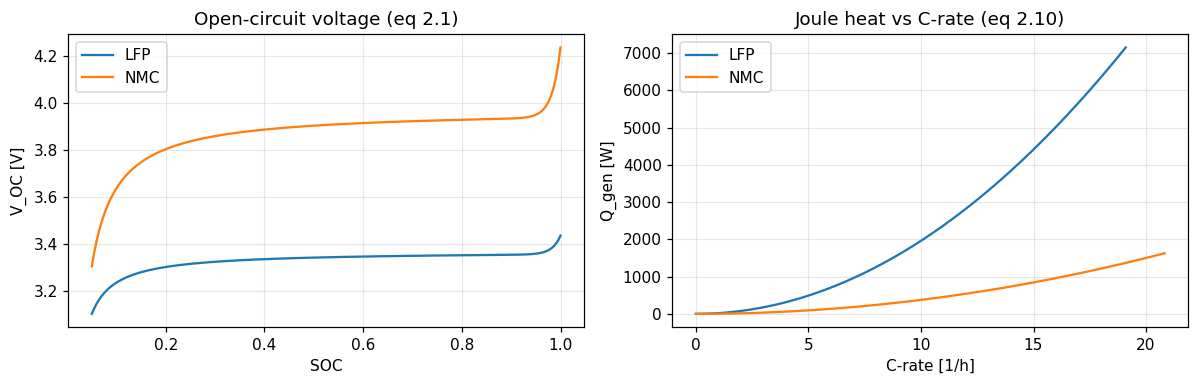

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
soc = np.linspace(0.05, 1.0, 200)
for tag, s in CELLS.items():
    p = shepherd_params(s)
    ax[0].plot(soc, v_oc(soc, p, s), label=tag)
ax[0].set(xlabel="SOC", ylabel="V_OC [V]", title="Open-circuit voltage (eq 2.1)")
ax[0].legend()
# Q_gen vs discharge power at SOC=0.5
for tag, s in CELLS.items():
    p = shepherd_params(s)
    voc = float(v_oc(0.5, p, s))
    Pmax = 0.24 * voc**2 / s.R_int
    P = np.linspace(1, Pmax, 200)
    I = current_from_power(P, voc, s.R_int)
    ax[1].plot(I / s.C_max, s.R_int * I**2, label=tag)
ax[1].set(xlabel="C-rate [1/h]", ylabel="Q_gen [W]", title="Joule heat vs C-rate (eq 2.10)")
ax[1].legend(); fig.tight_layout()

## 5 · Thermal model — lumped energy balance  *(corrected, v2)*

$$m_b c_p \frac{dT_b}{dt}=Q_{gen}-(h_c+h_r)A(T_b-T_{env})\tag{2.11}$$

The reference's explicit update (eq 2.12) as printed is only dimensionally valid for a
**1-second** step. Integrating with the correct step $\Delta t$ gives

$$T_b(t)=\frac{m_bc_p\,T_b(t-1)+\big[Q_{gen}(t)+(h_c+h_r)A\,T_{env}(t)\big]\Delta t}
{m_bc_p+(h_c+h_r)A\,\Delta t}\tag{2.12'}$$

which at steady state gives the physical $\Delta T=Q_{gen}/[(h_c+h_r)A]$.

Coefficients (air properties @300 K), with the **standard Churchill–Chu laminar
vertical-plate** correlation rather than the reference's non-standard split:

$$h_c=k_a\frac{Nu}{L_c},\quad Nu=0.59\,Ra^{1/4},\quad Ra=Gr\,Pr=\frac{g\beta\Delta T L_c^3}{\nu_a^2}Pr,\quad
\beta=\tfrac1{T_m};\qquad h_r=4\varepsilon\sigma T_m^3\tag{2.13'–2.17}$$

> **Four corrections applied in this version (why the thermal layer was previously inert):**
> 1. **Timestep bug fixed** — eq 2.12 → 2.12′. Previously each hourly step behaved like 1 s,
>    so self-heating was ~100× too small.
> 2. **`T_b` now drives the cycle law** (§6/§8). During cycling the cell runs at
>    $T_b=T_{env}+\Delta T_{self}(\text{C-rate})+\Delta T_{pack}$; the calendar (storage,
>    $Q\approx0$) stays at $T_{env}$.
> 3. **Pack self-heating** `dt_pack` [K] added on top of the single-cell rise (addresses the
>    single-cell⇒pack limitation, L8).
> 4. **Standard Nusselt + self-consistent $h(\Delta T)$** — $h_c,h_r$ are iterated on the
>    realized $\Delta T$ (a few Gauss–Seidel passes) instead of pre-fixing $\Delta T=5$ K.
>
> The **steady-state** rise is the right approximation for off-grid cycling (thermal time
> constant $\tau=m_bc_p/hA\sim1$ h ≪ the daily cycle), so distillation uses the steady
> $\Delta T$ at `CRATE_REF`.

In [5]:
def lateral_area(s: CellSpec):
    return ((s.N_series * s.T_L * s.H_L * 2) + (s.N_parallel * s.W_L * s.H_L * 2)) / s.N_batteries

def htc(s: CellSpec, T_env_K, dT):
    '''Convective + radiative coefficients [W/m2/K]. Churchill-Chu laminar (Nu=0.59 Ra^1/4).'''
    dT = max(float(dT), 0.1)                       # guard the correlation at ~0 driving dT
    Tm = T_env_K + dT / 2.0
    Lc = s.H_L
    Ra = (G * (1.0 / Tm) * dT * Lc**3 / NU_AIR**2) * PR_AIR
    Nu = 0.59 * Ra**0.25
    return K_AIR * Nu / Lc, 4.0 * s.emissivity * SIGMA * Tm**3

def steady_delta_T(s: CellSpec, T_env_K, Q_gen_W, iters=4):
    '''Self-consistent steady-state cell rise: dT = Q/hA with h iterated on dT.'''
    dT = 5.0; A = lateral_area(s)
    for _ in range(iters):
        h_c, h_r = htc(s, T_env_K, dT)
        dT = Q_gen_W / ((h_c + h_r) * A)
    return dT, (h_c + h_r) * A

def cell_temperature(Q_gen_W, T_env_K, s: CellSpec, dt=DT_STEP_S, isothermal=False):
    '''Transient T_b(t) with the corrected timestep (eq 2.12'). h fixed at the steady dT
       of the mean load, which is exact once the trajectory settles.'''
    Q_gen_W = np.asarray(Q_gen_W, float)
    if isothermal:
        return np.full_like(Q_gen_W, T_env_K)
    dT_ss, hA = steady_delta_T(s, T_env_K, float(np.mean(Q_gen_W)) if Q_gen_W.size else 0.0)
    mc = s.mass * s.c_p
    Tb = np.empty_like(Q_gen_W); prev = T_env_K
    for i, Q in enumerate(Q_gen_W):
        prev = (mc * prev + (Q + hA * T_env_K) * dt) / (mc + hA * dt)
        Tb[i] = prev
    return Tb

def operating_cell_temperature(s: CellSpec, T_env_C, crate, soc=0.5):
    '''Steady operating cell temperature during cycling: T_env + self-heating + pack offset.
       Used to evaluate the CYCLE law at the true cell temperature (correction #2).'''
    Tenv_K = T_env_C + KELVIN
    p = shepherd_params(s)
    voc = float(v_oc(soc, p, s))
    I = float(current_from_power(crate * s.C_max * voc, voc, s.R_int))
    Q = s.R_int * I**2
    dT_self, _ = steady_delta_T(s, Tenv_K, Q)
    return Tenv_K + dT_self + s.dt_pack

steady cell rise dT_self = Q_gen/hA  [K]   (T_env = 35 C)
  [LFP] 0.2C:  0.99 | 0.4C:  3.56 | 1.0C: 18.66   (+ dt_pack 3.0 K)
  [NMC] 0.2C:  0.59 | 0.4C:  2.14 | 1.0C: 11.38   (+ dt_pack 3.0 K)
LFP 0.4C steady self-heating: 3.56 K


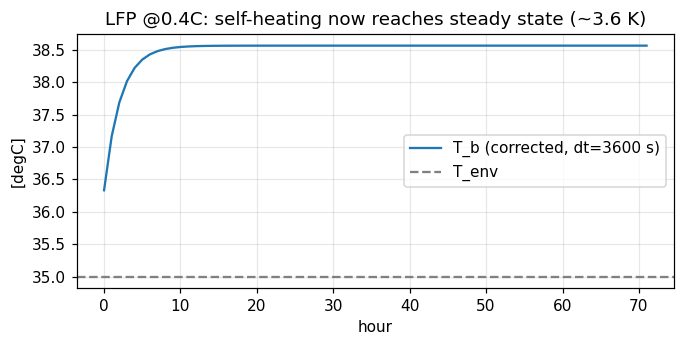

In [6]:
# steady self-heating vs C-rate (now physical), and the corrected transient
print("steady cell rise dT_self = Q_gen/hA  [K]   (T_env = 35 C)")
for tag, s in CELLS.items():
    row = []
    for cr in (0.2, 0.4, 1.0):
        p = shepherd_params(s); voc = float(v_oc(0.5, p, s))
        I = float(current_from_power(cr * s.C_max * voc, voc, s.R_int)); Q = s.R_int * I**2
        dT, _ = steady_delta_T(s, 35 + KELVIN, Q)
        row.append(f"{cr}C: {dT:5.2f}")
    print(f"  [{tag}] " + " | ".join(row) + f"   (+ dt_pack {s.dt_pack} K)")

s = LFP
hrs = np.arange(72)
Q = np.full(72, s.R_int * float(current_from_power(0.4 * s.C_max * v_oc(0.5, shepherd_params(s), s),
             float(v_oc(0.5, shepherd_params(s), s)), s.R_int))**2)
Tb = cell_temperature(Q, 35 + KELVIN, s)
plt.figure(figsize=(7, 3))
plt.plot(hrs, Tb - KELVIN, label="T_b (corrected, dt=3600 s)")
plt.axhline(35, ls="--", c="grey", label="T_env")
plt.xlabel("hour"); plt.ylabel("[degC]")
plt.title(f"LFP @0.4C: self-heating now reaches steady state (~{float(Tb[-1]-KELVIN-35):.1f} K)")
plt.legend(); print("LFP 0.4C steady self-heating:", round(float(Tb[-1]-KELVIN-35), 2), "K")

## 6 · Semi-empirical aging laws (calendar + cycle)

**Calendar** (Arrhenius in $1/T_b$, SOC-modulated; power-law in time). Cumulative % lost at
elapsed time $t$ [h]:

$$C_{loss,cal}(\%)=a_1e^{a_2\mathrm{SOC}}\,a_3e^{a_4/T_b}\,(t/24)^{a_5}\tag{2.19}$$

**Cycle** (chemistry-influenced stress factors), loss % per equivalent full cycle:

$$C_{loss,cyc}(\%)=b_1\exp\!\Big(b_2\tfrac{T_b-b_3}{T_b}+b_4\mathrm{DOD}+\text{C-rate}(b_5+b_6)\Big)
\big[1+b_7\,\mathrm{mSOC}(1-\tfrac{\mathrm{mSOC}}{2b_8})\big]\tag{2.20}$$

> **Two documented modeling decisions (the crux):**
> 1. **Calendar is a power law in time** ($a_5\approx0.5$) → fade is *sub-linear*. The distilled
>    `α_hour` is the **yearly-average** rate (total horizon loss / years / 8760), which flattens
>    the √t shape into a constant — the standard linearization.
> 2. **Per-cycle Ψ convention.** We read eq 2.20 as loss **per equivalent full cycle (EFC)** at
>    the operating point. A cycle to depth $D$ carries $D$ EFC of throughput (1 EFC = $2C_{max}$
>    Ah, eq 2.23), so the capacity lost by one cycle to depth $D$ is
>    $\;\Psi(D,T)=\big[C_{loss,cyc}(D,\cdot)/100/\text{Scaling}_{tot}\big]\cdot D$, with
>    $\mathrm{mSOC}=1-D/2$. This makes $\Psi$ increasing in $D$ and is consistent with how
>    MicroGridsPy consumes $\beta$ (fraction lost per unit throughput).
>
> The cycle law's $T_b$ is the **self-heated operating temperature** from §5
> ($T_{env}+\Delta T_{self}(\text{C-rate})+\Delta T_{pack}$), not bare ambient — this is what
> makes the thermal block actually influence the distilled $c_k$.

In [7]:
def calendar_pct_cumulative(soc, Tb_K, t_hours, a):
    a1, a2, a3, a4, a5 = a
    return a1 * np.exp(a2 * soc) * a3 * np.exp(a4 / Tb_K) * (t_hours / 24.0) ** a5

def cycle_pct_per_efc(DOD, mSOC, crate, Tb_K, b):
    b1, b2, b3, b4, b5, b6, b7, b8 = b
    stress = np.exp(b2 * (Tb_K - b3) / Tb_K + b4 * DOD + crate * (b5 + b6))
    msoc_term = 1.0 + b7 * mSOC * (1.0 - mSOC / (2.0 * b8))
    return b1 * stress * msoc_term

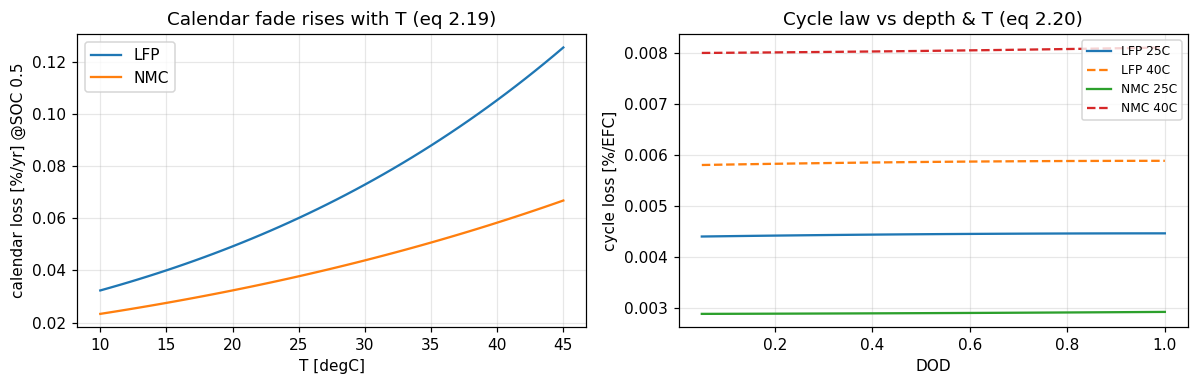

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
T = np.linspace(10, 45, 50)
for tag, s in CELLS.items():
    yr_pct = calendar_pct_cumulative(0.5, T + KELVIN, 8760.0, s.a)  # 1-yr cumulative %
    ax[0].plot(T, yr_pct, label=tag)
ax[0].set(xlabel="T [degC]", ylabel="calendar loss [%/yr] @SOC 0.5",
          title="Calendar fade rises with T (eq 2.19)"); ax[0].legend()
D = np.linspace(0.05, 1.0, 50)
for tag, s in CELLS.items():
    for Tc, ls in [(25, "-"), (40, "--")]:
        v = cycle_pct_per_efc(D, 1 - D/2, CRATE_REF, Tc + KELVIN, s.b)
        ax[1].plot(D, v, ls, label=f"{tag} {Tc}C")
ax[1].set(xlabel="DOD", ylabel="cycle loss [%/EFC]", title="Cycle law vs depth & T (eq 2.20)")
ax[1].legend(fontsize=8); fig.tight_layout()

## 7 · Calibration to the datasheet

The lab laws are anchored to *this* battery through the datasheet cycle-life point
("$N$ cycles to $\mathrm{SOH}_{eol}$ at DoD/T/C-rate"). Two corrections (Andrade §2.5):

$$X_T=-0.01875\,(T_b-273.15)+1.46875\tag{2.33}\qquad
\text{Scaling}_{tot}=\text{Scaling}_{cap}\,X_c\,X_T\tag{2.31}$$

We set $\text{Scaling}_{cap}=1$: the %-laws are intensive, and **$X_c$ (back-solved to hit the
datasheet EOL) absorbs any lab-cell provenance** — so no `C_b,study` guess is needed.

> **Calibration temperature convention.** Datasheet cycle life is a *controlled-temperature*
> spec, so calibration evaluates the law at the bare `test_T_C` (**no self-heating added**) and
> at the datasheet `test_crate`. Field distillation (§8) instead uses the self-heated operating
> $T_b$ at `CRATE_REF`. The asymmetry is deliberate and physical: the sheet is measured at a
> held temperature; the field cell runs hotter than room ambient.

Because the cycle law has no SoH-knee, accumulation is linear and $X_c$ is **closed-form**:

$$X_c=\frac{N_{cycles}\,\big[C_{loss,cyc}(\text{test})/100\big]\,\mathrm{DOD}_{test}}
{\text{Scaling}_{cap}\,X_T\,(1-\mathrm{SOH}_{eol})}$$

In [9]:
def X_T(Tb_K):
    return -0.01875 * (Tb_K - KELVIN) + 1.46875

def calibrate(s: CellSpec) -> dict:
    Scaling_cap = 1.0
    Tref = s.test_T_C + KELVIN
    xt = X_T(Tref)
    raw = cycle_pct_per_efc(s.test_DOD, 1 - s.test_DOD / 2, s.test_crate, Tref, s.b)
    X_c = (s.N_cycles * (raw / 100.0) * s.test_DOD) / (Scaling_cap * xt * (1.0 - s.EOL_SOH))
    return dict(Scaling_cap=Scaling_cap, X_c=X_c, X_T_ref=xt, raw_pct=raw)

def scaling_tot(s, cal, Tb_K):
    return cal["Scaling_cap"] * cal["X_c"] * X_T(Tb_K)

CAL = {tag: calibrate(s) for tag, s in CELLS.items()}
for tag, cal in CAL.items():
    s = CELLS[tag]
    # verify: N_cycles full cycles reproduce EOL
    w = cycle_pct_per_efc(s.test_DOD, 1 - s.test_DOD/2, s.test_crate, s.test_T_C+KELVIN, s.b)/100/scaling_tot(s, cal, s.test_T_C+KELVIN)
    soh_end = 1 - s.N_cycles * w * s.test_DOD
    print(f"[{tag}] X_c={cal['X_c']:.4f}  ->  SoH@{int(s.N_cycles)}cyc = {soh_end:.4f} "
          f"(target {s.EOL_SOH})")
    assert abs(soh_end - s.EOL_SOH) < 1e-6

[LFP] X_c=1.7005  ->  SoH@6000cyc = 0.8000 (target 0.8)
[NMC] X_c=0.4675  ->  SoH@2500cyc = 0.8000 (target 0.8)


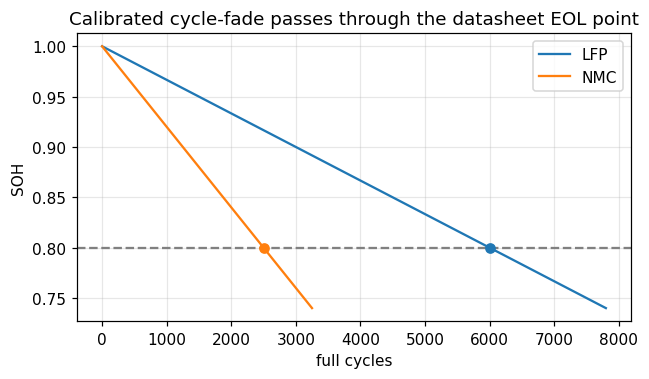

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
for tag, s in CELLS.items():
    cal = CAL[tag]
    n = np.linspace(0, s.N_cycles * 1.3, 100)
    w = cycle_pct_per_efc(s.test_DOD, 1-s.test_DOD/2, s.test_crate, s.test_T_C+KELVIN, s.b)/100/scaling_tot(s, cal, s.test_T_C+KELVIN)
    ax.plot(n, 1 - n * w * s.test_DOD, label=tag)
    ax.scatter([s.N_cycles], [s.EOL_SOH], zorder=5)
ax.axhline(0.8, ls="--", c="grey"); ax.set(xlabel="full cycles", ylabel="SOH",
    title="Calibrated cycle-fade passes through the datasheet EOL point"); ax.legend()

## 8 · Distillation protocol (documented & reproducible)

Three passes produce the surrogates tabulated over `TEMP_GRID_C`:

- **α(T, SoC-band)** — storage mode (fixed SoC, no cycling ⇒ $Q_{gen}\approx0$, $T_b\approx T_{env}$):
  cumulative calendar % over the horizon → yearly-average fraction → `/8760`; cubic-fit in
  $y=T/10$. Bands = storage SoC 20 % and 40 %.
- **Ψ(D,T) → cₖ(T)** — cycle runs on a fine depth grid (`BAND_EDGES`, anchored at $\Psi(0)=0$)
  → per-band marginals $c_k=\Delta\Psi/\Delta D$ → **convexity guard** (pool-adjacent-violators)
  → cubic-fit per band. Because the law is continuous in $D$, the shallow bands are *computed,
  not extrapolated*.
- **β(T, DoD-band)** — legacy single coefficient $\beta=\Psi(D)/(2D)$ per mgpy DoD band.

In [11]:
def alpha_hour(s, cal, soc_band, T_env_C, horizon_years=HORIZON_YEARS):
    Tb = T_env_C + KELVIN                       # storage: Tb ~ T_env
    tot = calendar_pct_cumulative(soc_band, Tb, horizon_years * 8760.0, s.a) / 100.0
    return (tot / cal["Scaling_cap"] / horizon_years) / 8760.0

def psi_fraction(s, cal, D, T_env_C, crate=CRATE_REF):
    # cycle law is evaluated at the SELF-HEATED cell temperature (correction #2):
    Tb = operating_cell_temperature(s, T_env_C, crate, soc=1 - D / 2)
    w = cycle_pct_per_efc(D, 1 - D/2, crate, Tb, s.b) / 100.0 / scaling_tot(s, cal, Tb)
    return w * D                                # eq-2.23-consistent per-cycle loss fraction

def band_marginals(s, cal, T_env_C, edges=BAND_EDGES):
    psi = np.array([psi_fraction(s, cal, D, T_env_C) for D in edges])
    return psi, np.diff(psi) / np.diff(edges)

def isotonic_nondecreasing(c):
    '''Pool-adjacent-violators -> nearest non-decreasing sequence (convex guard, §L5).'''
    vals = [[float(v), 1.0] for v in c]; k = 0
    while k < len(vals) - 1:
        if vals[k][0] > vals[k+1][0] + 1e-18:
            w = vals[k][1] + vals[k+1][1]
            vals[k] = [(vals[k][0]*vals[k][1] + vals[k+1][0]*vals[k+1][1]) / w, w]
            del vals[k+1]; k = max(k-1, 0)
        else:
            k += 1
    out = []
    for v, w in vals: out.extend([v]*int(round(w)))
    return np.array(out[:len(c)])

def fit_cubic(T_C, values):          # returns (c1,c2,c3,c4), high->low powers of y=T/10
    return tuple(np.polyfit(np.asarray(T_C)/10.0, values, 3))

def beta_legacy(s, cal, D, T_env_C):
    return psi_fraction(s, cal, D, T_env_C) / (2.0 * D)

# ---- run the full distillation for both cells ----
def distill(tag):
    s, cal = CELLS[tag], CAL[tag]
    alpha_poly = {k: fit_cubic(TEMP_GRID_C, [alpha_hour(s, cal, band, T) for T in TEMP_GRID_C])
                  for k, band in SOC_BANDS.items()}
    # c_k(T): marginals per band at each T, guarded, then cubic per band
    Ck = np.array([isotonic_nondecreasing(band_marginals(s, cal, T)[1]) for T in TEMP_GRID_C])
    ck_poly = [fit_cubic(TEMP_GRID_C, Ck[:, kb]) for kb in range(Ck.shape[1])]
    beta_poly = {float(D): fit_cubic(TEMP_GRID_C, [beta_legacy(s, cal, D, T) for T in TEMP_GRID_C])
                 for D in DOD_BANDS_LEG}
    convex_all = bool(np.all([np.all(np.diff(band_marginals(s, cal, T)[1]) >= -1e-15)
                              for T in TEMP_GRID_C]))
    return dict(alpha_poly=alpha_poly, ck_poly=ck_poly, beta_poly=beta_poly,
                edges=BAND_EDGES.tolist(), convex_raw_all_T=convex_all)

DIST = {tag: distill(tag) for tag in CELLS}
for tag in CELLS:
    print(f"[{tag}] alpha40@25C={alpha_hour(CELLS[tag],CAL[tag],0.4,25):.3e}/h  "
          f"raw-convex(all T)={DIST[tag]['convex_raw_all_T']}")

[LFP] alpha40@25C=1.265e-08/h  raw-convex(all T)=False
[NMC] alpha40@25C=9.430e-09/h  raw-convex(all T)=True


## 9 · Visualization — surrogates & convexity

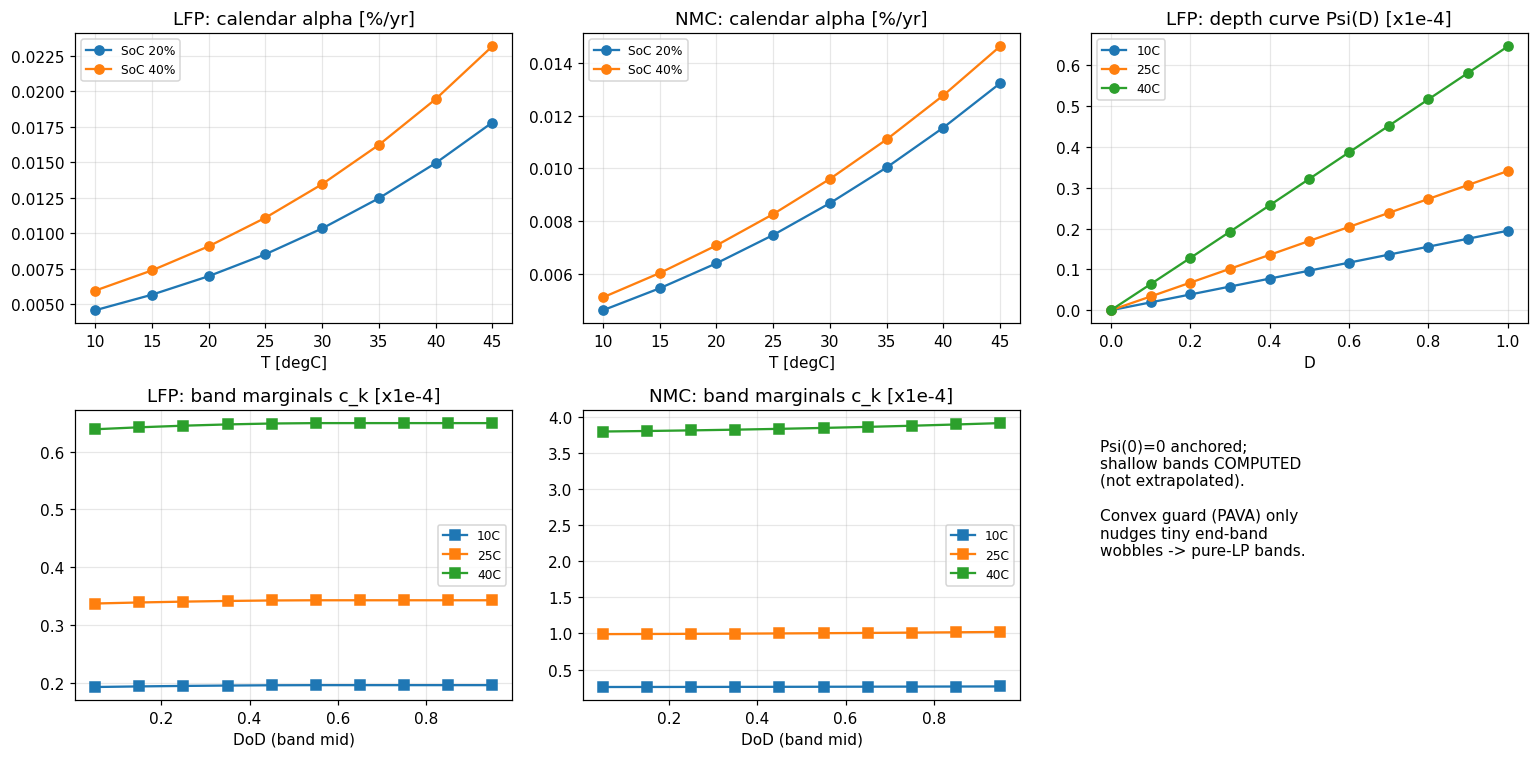

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
for col, tag in enumerate(CELLS):
    s, cal = CELLS[tag], CAL[tag]
    # alpha(T)
    for k, band in SOC_BANDS.items():
        ax[0, col].plot(TEMP_GRID_C, [alpha_hour(s, cal, band, T)*8760*100 for T in TEMP_GRID_C],
                        "o-", label=f"SoC {k}%")
    ax[0, col].set(title=f"{tag}: calendar alpha [%/yr]", xlabel="T [degC]"); ax[0, col].legend(fontsize=8)
    # c_k across depth at 3 temps
    mids = 0.5*(BAND_EDGES[:-1] + BAND_EDGES[1:])
    for Tc in (10, 25, 40):
        c = isotonic_nondecreasing(band_marginals(s, cal, Tc)[1])
        ax[1, col].plot(mids, c*1e4, "s-", label=f"{Tc}C")
    ax[1, col].set(title=f"{tag}: band marginals c_k [x1e-4]", xlabel="DoD (band mid)")
    ax[1, col].legend(fontsize=8)
# Psi(D,T) surface for LFP
s, cal = LFP, CAL["LFP"]
for Tc in (10, 25, 40):
    ax[0, 2].plot(BAND_EDGES, [psi_fraction(s, cal, D, Tc)*1e4 for D in BAND_EDGES], "-o", label=f"{Tc}C")
ax[0, 2].set(title="LFP: depth curve Psi(D) [x1e-4]", xlabel="D"); ax[0, 2].legend(fontsize=8)
ax[1, 2].axis("off")
ax[1, 2].text(0.02, 0.5, "Psi(0)=0 anchored;\nshallow bands COMPUTED\n(not extrapolated).\n\n"
              "Convex guard (PAVA) only\nnudges tiny end-band\nwobbles -> pure-LP bands.", fontsize=10)
fig.tight_layout()

## 10 · Internal self-consistency test

The essential no-cross-check validation: simulate one deep daily cycle + calendar for a year via
(a) the **full SEM law** stepwise and (b) the **distilled linear surrogates**
($\alpha\cdot\text{hours}+\sum_k c_k e_k$), both at the identical self-heated $T_b$.

This isolates the **band piecewise-linear residual**: $\sum_k c_k e_k$ reconstructs the PWL
interpolant of $\Psi$, while the SEM uses the exact $\Psi(\mathrm{DOD})$. On a band **edge** the
two are equal by telescoping (interpolant matches the curve), so we deliberately probe **off-edge**
DODs (0.45 / 0.63 / 0.87) to expose the genuine interpolation error. A small $|\Delta\mathrm{SOH}|$
confirms the depth banding is faithful to the depth curve it was distilled from. *(This is
self-consistency, not external validation — see the scope box.)*

In [13]:
def sem_soh(s, cal, dailyDOD, T_env_C, days=365, crate=CRATE_REF):
    # cycle at self-heated T_b; calendar in storage-consistent T_env (matches how alpha is distilled)
    Tb_cyc = operating_cell_temperature(s, T_env_C, crate, soc=1 - dailyDOD / 2)
    Tb_cal = T_env_C + KELVIN
    w = cycle_pct_per_efc(dailyDOD, 1-dailyDOD/2, crate, Tb_cyc, s.b)/100/scaling_tot(s, cal, Tb_cyc)
    cyc = days * w * dailyDOD
    cal_pct = calendar_pct_cumulative(1-dailyDOD/2, Tb_cal, days*24.0, s.a) / cal["Scaling_cap"]
    return 1 - cyc - cal_pct/100

def lin_soh(s, cal, dailyDOD, T_env_C, days=365, edges=BAND_EDGES):
    a_h = alpha_hour(s, cal, 1-dailyDOD/2, T_env_C, horizon_years=1)   # calendar: T_env
    cal_lost = a_h * days * 24.0
    c = isotonic_nondecreasing(band_marginals(s, cal, T_env_C, edges)[1])  # cycle: self-heated (via psi)
    e = np.clip(np.minimum(edges[1:], dailyDOD) - edges[:-1], 0, None)  # energy per band per cycle
    return 1 - days * np.sum(c * e) - cal_lost

rows = []
for tag in CELLS:
    for D in (0.45, 0.63, 0.87):     # off band-edges -> exposes the true PWL residual
        for Tc in (15, 25, 40):
            f = sem_soh(CELLS[tag], CAL[tag], D, Tc); l = lin_soh(CELLS[tag], CAL[tag], D, Tc)
            rows.append((tag, D, Tc, f, l, abs(f-l)))
df = pd.DataFrame(rows, columns=["cell", "dailyDOD", "T_C", "SEM_SOH", "lin_SOH", "abs_err"])
print(df.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
print(f"\nmax |dSOH| over grid = {df.abs_err.max():.2e}  (1-yr horizon)")

cell  dailyDOD  T_C  SEM_SOH  lin_SOH  abs_err
 LFP   0.45000   15  0.99560  0.99560  0.00000
 LFP   0.45000   25  0.99356  0.99356  0.00000
 LFP   0.45000   40  0.98791  0.98791  0.00000
 LFP   0.63000   15  0.99412  0.99413  0.00000
 LFP   0.63000   25  0.99140  0.99140  0.00000
 LFP   0.63000   40  0.98382  0.98382  0.00000
 LFP   0.87000   15  0.99214  0.99214  0.00000
 LFP   0.87000   25  0.98851  0.98851  0.00000
 LFP   0.87000   40  0.97832  0.97833  0.00001
 NMC   0.45000   15  0.99299  0.99299  0.00000
 NMC   0.45000   25  0.98324  0.98324  0.00000
 NMC   0.45000   40  0.93679  0.93678  0.00001
 NMC   0.63000   15  0.99030  0.99030  0.00000
 NMC   0.63000   25  0.97667  0.97667  0.00000
 NMC   0.63000   40  0.91158  0.91157  0.00001
 NMC   0.87000   15  0.98668  0.98668  0.00000
 NMC   0.87000   25  0.96784  0.96784  0.00000
 NMC   0.87000   40  0.87768  0.87767  0.00001

max |dSOH| over grid = 6.99e-06  (1-yr horizon)


## 11 · Export — MicroGridsPy-matching coefficients

The engine emits a JSON whose structure mirrors
`microgridspy/data_pipeline/battery_degradation_coefficients.py`:
`alpha_poly[chem][soc_band]`, `beta_poly[chem][dod_band]` (legacy single-β), and the new
`ck_bands[chem]` (edges + per-band cubic). A `meta` block stamps the inputs and a protocol
hash for full traceability.

> **Units contract (do not skip on the mgpy side):** `α` = fraction of nameplate energy lost
> per hour; `β` and `cₖ` = fraction of nameplate lost per unit of nameplate-energy throughput
> (charge+discharge summed). Cubics are in `y = T[°C]/10`, high→low power order.

In [14]:
OUT_DIR = Path.cwd()
def build_export():
    payload = {"meta": {"generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
                        "units": {"alpha": "frac_nameplate_per_hour",
                                  "beta_ck": "frac_nameplate_per_unit_throughput",
                                  "cubic_arg": "y = T[degC]/10, high->low"},
                        "protocol": {"temp_grid_C": TEMP_GRID_C.tolist(),
                                     "band_edges": BAND_EDGES.tolist(),
                                     "distillation_crate": CRATE_REF, "horizon_years": HORIZON_YEARS,
                                     "calibration_crate": "per-cell datasheet test_crate",
                                     "thermal": "cycle law at T_env+self-heating(crate)+dt_pack; "
                                                "calendar at T_env; eq 2.12' with dt=3600 s; "
                                                "Nu=0.59 Ra^0.25 with h(dT) iteration"}},
               "alpha_poly": {}, "beta_poly": {}, "ck_bands": {}}
    for tag, s in CELLS.items():
        d = DIST[tag]
        payload["meta"].setdefault("cells", {})[tag] = {
            **{k: v for k, v in asdict(s).items() if not isinstance(v, tuple)},
            "calibration": {k: float(v) for k, v in CAL[tag].items()}}
        payload["alpha_poly"][tag] = {k: [float(x) for x in poly] for k, poly in d["alpha_poly"].items()}
        payload["beta_poly"][tag] = {str(k): [float(x) for x in poly] for k, poly in d["beta_poly"].items()}
        payload["ck_bands"][tag] = {"edges": d["edges"],
                                    "poly": [[float(x) for x in poly] for poly in d["ck_poly"]]}
    blob = json.dumps(payload, indent=2, sort_keys=True)
    payload["meta"]["protocol_sha1"] = hashlib.sha1(blob.encode()).hexdigest()[:12]
    return payload

EXPORT = build_export()
path = OUT_DIR / "layer1_liion_coefficients.json"
path.write_text(json.dumps(EXPORT, indent=2))
print("wrote", path)
print("protocol_sha1:", EXPORT["meta"]["protocol_sha1"])
print("alpha_poly LFP:", EXPORT["alpha_poly"]["LFP"])

wrote C:\Users\onori\Documents\GitHub\MicroGridsPy-SESAM\MicroGridsPy\notebooks\layer1_liion_coefficients.json
protocol_sha1: 140889b01bc1
alpha_poly LFP: {'20': [5.443285170328373e-11, 2.199259848757097e-10, 1.6959059130470221e-09, 3.2561836010059717e-09], '40': [7.083603663289412e-11, 2.862000544469213e-10, 2.2069623329195123e-09, 4.237425261156644e-09]}


## 12 · Scale & customize a battery — the MicroGridsPy user flow

This mirrors what a user does *inside MicroGridsPy*: pick one of the two archetypes, then scale
it to their own battery through the same lever mgpy uses — the **cycle-life ratio**
`N_ref / N_user` on the cycle term — plus their own ambient temperature and DoD cap. The engine
returns the degradation pathway (SoH vs. year) so the user can see the impact before running the
full sizing model.

Example: LFP archetype scaled to N_user=4000, DoD 0.9, 38C
  cycle 2.903%/yr + calendar 0.1046%/yr -> reaches 80% at year 7


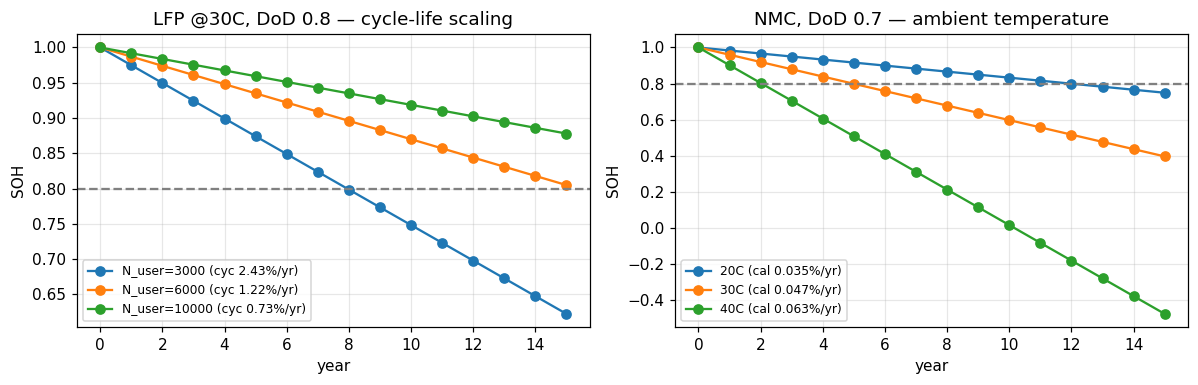

In [15]:
def degradation_pathway(base="LFP", *, N_user=None, dailyDOD=0.8, T_env_C=25.0,
                        cycles_per_year=365, years=15):
    '''Project SoH(year) for a scaled archetype using the distilled surrogates.
       cycle term scaled by N_ref/N_user exactly as MicroGridsPy does.'''
    s, cal = CELLS[base], CAL[base]
    scale = 1.0 if not N_user else CELLS[base].N_ref / float(N_user)
    a_h = alpha_hour(s, cal, 1 - dailyDOD/2, T_env_C, horizon_years=1)
    c = isotonic_nondecreasing(band_marginals(s, cal, T_env_C)[1]) * scale
    e = np.clip(np.minimum(BAND_EDGES[1:], dailyDOD) - BAND_EDGES[:-1], 0, None)
    cyc_per_year = cycles_per_year * float(np.sum(c * e))
    cal_per_year = a_h * 8760.0
    yr = np.arange(years + 1)
    return yr, 1 - yr * (cyc_per_year + cal_per_year), cyc_per_year, cal_per_year

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
# (a) effect of user cycle-life rating on an LFP archetype
for Nu in (3000, 6000, 10000):
    yr, soh, cyc, cal_ = degradation_pathway("LFP", N_user=Nu, dailyDOD=0.8, T_env_C=30)
    ax[0].plot(yr, soh, "-o", label=f"N_user={Nu} (cyc {cyc*100:.2f}%/yr)")
ax[0].axhline(0.8, ls="--", c="grey"); ax[0].set(title="LFP @30C, DoD 0.8 — cycle-life scaling",
    xlabel="year", ylabel="SOH"); ax[0].legend(fontsize=8)
# (b) effect of ambient temperature (NMC)
for Tc in (20, 30, 40):
    yr, soh, cyc, cal_ = degradation_pathway("NMC", dailyDOD=0.7, T_env_C=Tc)
    ax[1].plot(yr, soh, "-o", label=f"{Tc}C (cal {cal_*100:.3f}%/yr)")
ax[1].axhline(0.8, ls="--", c="grey"); ax[1].set(title="NMC, DoD 0.7 — ambient temperature",
    xlabel="year", ylabel="SOH"); ax[1].legend(fontsize=8); fig.tight_layout()

print("Example: LFP archetype scaled to N_user=4000, DoD 0.9, 38C")
yr, soh, cyc, cal_ = degradation_pathway("LFP", N_user=4000, dailyDOD=0.9, T_env_C=38)
yr80 = yr[soh < 0.8]
print(f"  cycle {cyc*100:.3f}%/yr + calendar {cal_*100:.4f}%/yr -> "
      f"reaches 80% at year {'>%d'%yr[-1] if len(yr80)==0 else yr80[0]}")

---
### Handoff & limitations
- **Handoff:** `layer1_liion_coefficients.json` drops into a MicroGridsPy *coefficient provider*
  (the "provider seam"): `alpha_poly` / `beta_poly` match the existing tables; `ck_bands` feeds
  the new depth-band cycle term.
- **Limitations carried:** L1 no SoH-knee (bands resolve depth, not age); L3 empirical foundation
  (self-consistent ≠ ground truth — external validation still required); L4 band separability;
  L8 single-cell. Calendar magnitude follows the raw Ali law (intensive); anchor it to a datasheet
  calendar life if one is available.